In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [2]:
base_path = "/Users/ktt_0900_jsm/ml/resouce/datasets"
file_name = "banknote_authentication.csv"
file_path = os.path.join(base_path, file_name)

In [4]:
bank_df = pd.read_csv(file_path)
bank_df



,variance,skewness,curtosis,entropy,class
0,3.62160,8.66610,-2.8073,-0.44699,0
1,4.54590,8.16740,-2.4586,-1.46210,0
2,3.86600,-2.63830,1.9242,0.10645,0
3,3.45660,9.52280,-4.0112,-3.59440,0
4,0.32924,-4.45520,4.5718,-0.98880,0
...,...,...,...,...,...
1367,0.40614,1.34920,-1.4501,-0.55949,1
1368,-1.38870,-4.87730,6.4774,0.34179,1
1369,-3.75030,-13.45860,17.5932,-2.77710,1
1370,-3.56370,-8.38270,12.3930,-1.28230,1


## SVM
- Banknote Authentication 데이터셋은 진짜 지폐와 위조 지폐 이미지를 복잡하고 일그러진 이미지(또는 신호)를 작은 물결 모양의 조각(Wavelet)들로 쪼개서,  
  눈에 잘 안 보이는 패턴 특징을 뽑아내는 기술 웨이블릿 변환하여 추출한 4가지 연속형 특성으로 구성된 이진 분류 데이터입니다.

[Banknote Authentication 데이터셋](https://archive.ics.uci.edu/dataset/267/banknote+authentication)

### 데이터셋 컬럼 명세 (Metadata)

| 컬럼명 | 데이터 타입 | 데이터 범위 (Min ~ Max) | 구분 | 설명 |
| :--- | :---: | :---: | :---: | :--- |
| **variance** | `float64` | -7.0421 ~ 6.8248 | Feature | 웨이블릿 변환 이미지의 변량 (지폐 선명도 및 질감 변동 폭) |
| **skewness** | `float64` | -13.7731 ~ 12.9516 | Feature | 웨이블릿 변환 이미지의 왜도 (명암 분포의 비대칭성) |
| **curtosis** | `float64` | -5.2861 ~ 17.9274 | Feature | 웨이블릿 변환 이미지의 첨도 (명암 분포의 돌출도) |
| **entropy** | `float64` | -8.5801 ~ 2.4495 | Feature | 이미지 정보의 엔트로피 (무작위성 및 정보 복잡도) |
| **class** | `int64` | 0 또는 1 | Target | 지폐 진위 여부 (**0**: 진짜 지폐 / **1**: 위조 지폐) |

### 데이터셋의 상세 설명
- variance (변량): 미세 질감이 얼마나 일정하게 오르락내리락하는가? (지폐 질감 선명도)
- skewness (왜도): 명암이나 잉크 굵기 패턴이 한쪽으로 쏠려 있는가?
- curtosis (첨도): 잉크 경계선이나 미세 선들이 얼마나 뾰족하고 매섭게 인쇄되었는가?
- entropy (엔트로피): 미세 패턴이 얼마나 복잡하고 무작위적인가?

## 1단계, 데이터 탐색

In [5]:
bank_df.info()

# 낫어넘버가 있는지, 수치형인지 분류형인지 확인해야함.

<class 'pandas.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [6]:
bank_df.describe()

#이상치로 보기 어렵다. 120넘어가고 막 이런 거 아니면. 특히 위조지폐는 뒤틀기나 어쩌고 그럴 가능성 있음. 

,variance,skewness,curtosis,entropy,class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


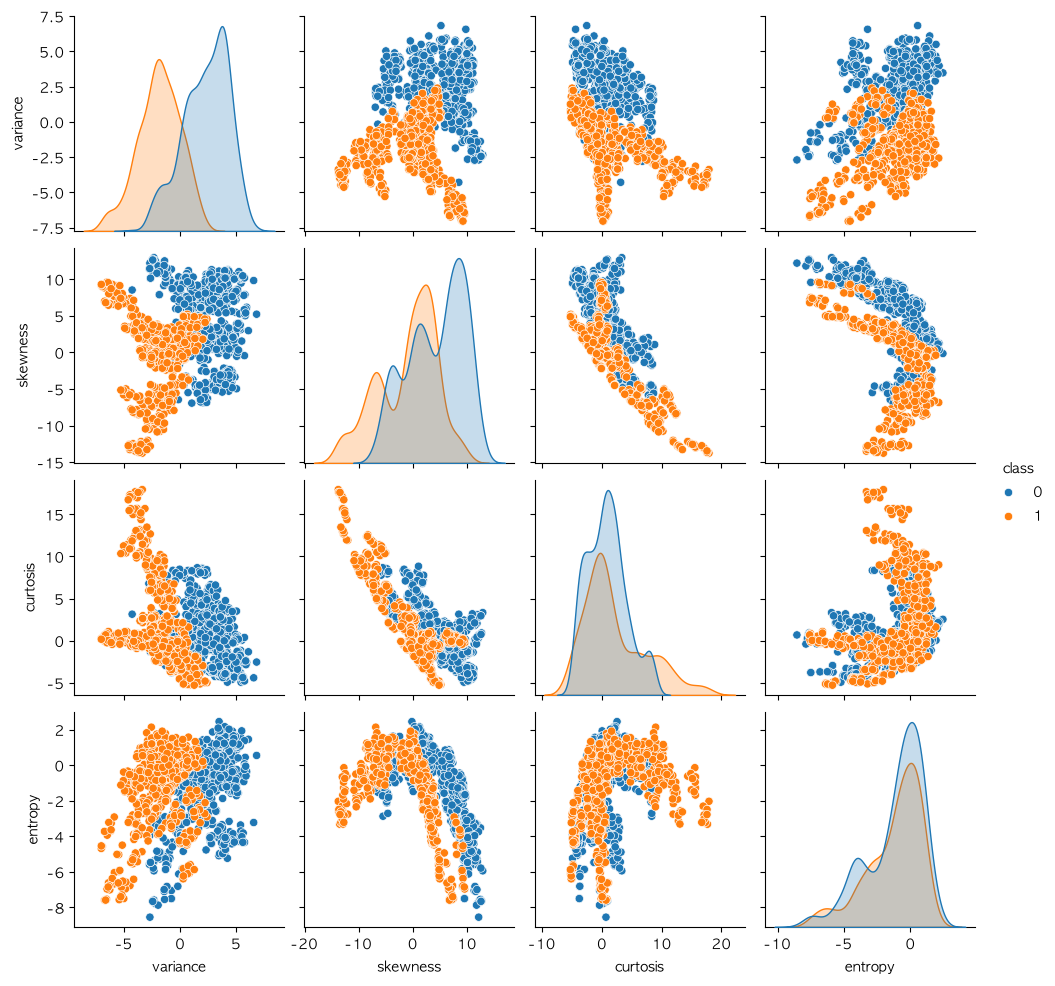

In [7]:
sns.pairplot(bank_df, hue="class") # hue하면 색 구분이 가능함
plt.show()

In [9]:
X = bank_df.drop("class", axis=1) # 특성이 여러개라 X대문자
X.head()

,variance,skewness,curtosis,entropy
0,3.62160,8.6661,-2.8073,-0.44699
1,4.54590,8.1674,-2.4586,-1.46210
2,3.86600,-2.6383,1.9242,0.10645
3,3.45660,9.5228,-4.0112,-3.59440
4,0.32924,-4.4552,4.5718,-0.98880


In [10]:
y = bank_df["class"] # 정답은 하나라서 소문자 y
y.head()

0    0
1    0
2    0
3    0
4    0
Name: class, dtype: int64

## 2단계, 데이터 분할 (원래는 2단계가 결측치 확인)

In [11]:
# 정답 데이터와 학습 데이터를 구분해주자
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=2026, stratify = y) #트테트테
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1097, 4) (275, 4) (1097,) (275,)


In [ ]:
abcd기 정답인 y에 얼마나 영향을 미치냐. 가중치를 구해야하는데, 학습되면서 해주니까 신경 안 썼는데,
각각의 특성 주는 영향력이 다를 수 있음. 단위가 다르기 때문에.그래서 같은 가중치를 주면 안 됨. 
    -> 단위를 비슷하게 만들어주는 과정이 필요함. 서로 같은 영향을 주기 위해. ---> 표준화와 정규화


## 표준화 또는 정규화
- scikit-learn의 preprocessing 모듈
    - 데이터 전처리는 많은 작업들을 하게 되는데 대표적인 것이 scaling이다.
    데이터의 feature scaling이라고 한다. 데이터들의 단위를 맞춘다는 느낌.
    이 것은 크게 두가지 방법이 있는데
        1. 표준화 (standardization)
            - 평균을 기준으로 표준 편차만큼 동등하게 변경
            - 기준점(평균)을 가지고 값을 배치하는 거.
        2. 정규화 (nomalization)
             0 ~ 1사이의 값으로 변경 (가장 큰 값이 1역할을 하게 됨.)
           이상치가 있으면 영향을 많이 받음.-> 정규화 하면 안 됨
    정규화와 표준화는 모두 머신러닝 알고리즘을 훈련시키는데 있어서 사용되는 특성(feature)들이  
    '모두 비슷한 영향력'을 행사하도록 값을 변환해주는 전처리 기술이다.

In [15]:
# 표준화 
from sklearn.preprocessing import StandardScaler
     # 전처리 모델의                  #스탠다드 스케일러
scaler = StandardScaler()

#fit_transform: 평균과 표준편차를 모두 구하고 표준화
X_train_scaled = scaler.fit_transform(X_train)
#transform: 구해진 평균과 표준편차를 이용해서 표준화. 두 개가 다른 표준을 이용하면 안 되기 때문에 2번째에는 fit 안 한 거
X_test_scaled =scaler.transform(X_test)      #train에서 만든 평균을 통해서 해야하기 떄문에 fit이 안 들어감.

In [17]:
print(X_train_scaled[1])
X_train.loc[780]
# 단위가 줄어들면서 값들을 좀 맞췄다!

[-1.41012125 -2.5246267   2.73858777 -0.63924813]


variance    -3.5801
skewness   -12.9309
curtosis    13.1779
entropy     -2.5677
Name: 780, dtype: float64

## 3단계, 모델 준비

In [19]:
from sklearn.svm import SVC

In [20]:
svc = SVC()

## 4단계, 모델 학습

In [21]:
svc.fit(X_train_scaled, y_train)   #학습데이터와 학습의 정답 데이터 전달해야함

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


## 5단계, 모델 예측

In [27]:
y_pred = svc.predict(X_test_scaled)
#예측값
print(y_pred[:10])

#정답지
print(list(y_test)[:10])

#모델 학습이 완료됨

[1 1 0 0 0 1 1 1 1 1]
[1, 1, 0, 0, 0, 1, 1, 1, 1, 1]


## 6단계, 모델 평가

In [29]:
# 학습데이터도 다 맞춤
svc.score(X_train_scaled, y_train)


1.0

In [30]:
# 테스트 데이터도 다 맞춤
svc.score(X_test_scaled, y_test)


1.0

In [32]:
columns = X_train.columns
columns

scaled_df = pd.DataFrame(X_train_scaled, columns=columns)
scaled_df["class"] = y
scaled_df.head()

,variance,skewness,curtosis,entropy,class
0,0.811353,0.690901,-0.434232,0.253388,0
1,-1.410121,-2.524627,2.738588,-0.639248,0
2,-0.023973,0.445474,0.152557,0.492855,0
3,0.794838,0.956707,-0.392191,-0.210787,0
4,1.155161,0.634380,-0.724739,0.470080,0


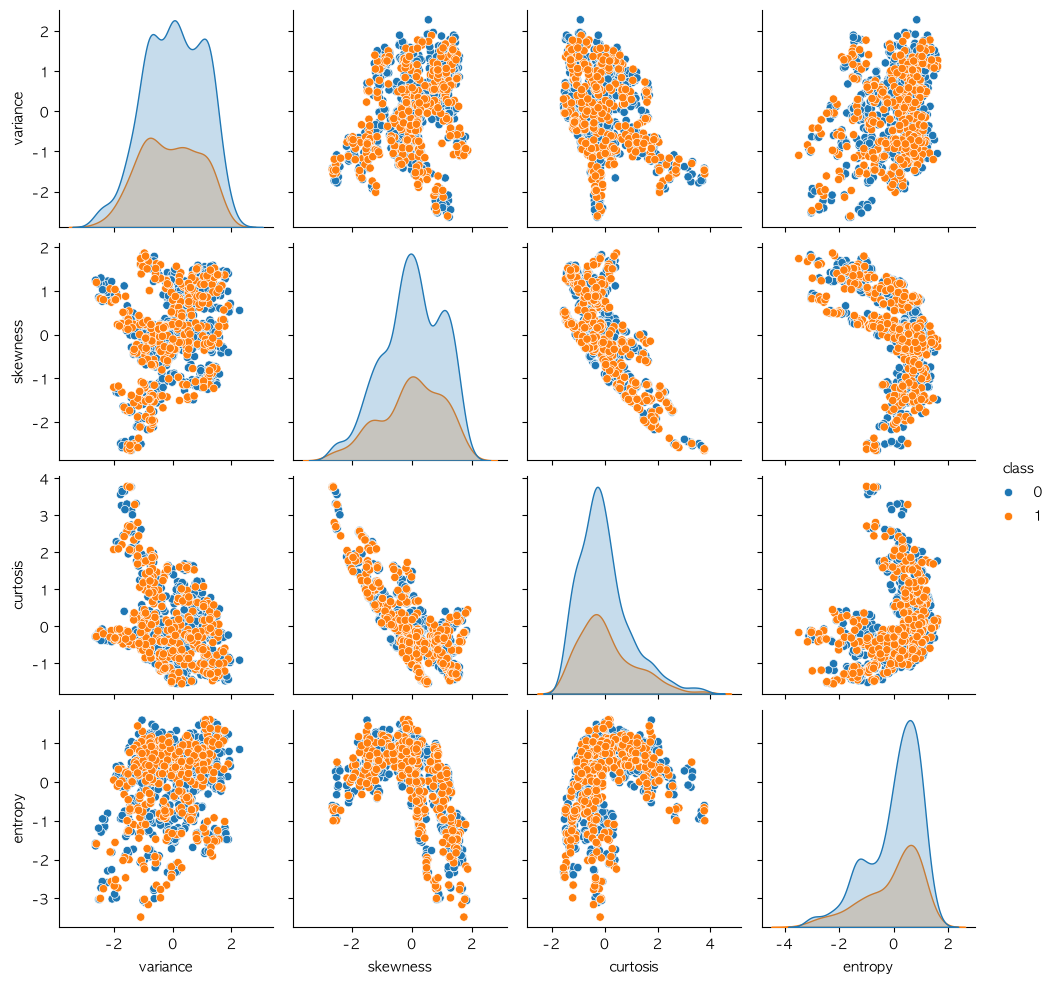

In [33]:
sns.pairplot(scaled_df, hue="class")

In [37]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [38]:
accuracy_score(y_pred, y_test)

1.0

In [41]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[153,   0],
       [  0, 122]])

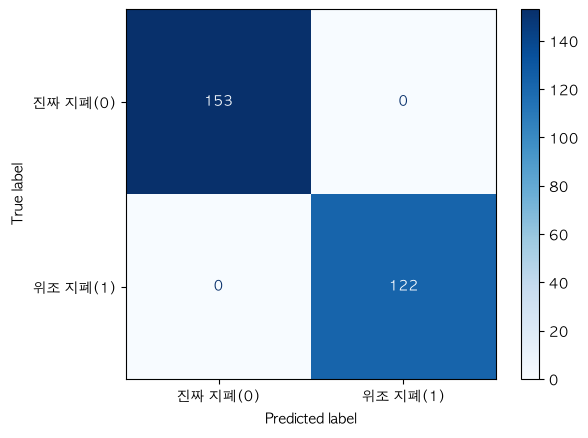

In [44]:
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["진짜 지폐(0)", "위조 지폐(1)"])
cm_display.plot(cmap="Blues")
plt.show()

In [46]:
# 조화 평균
# 정밀도(precision;양성이라고 생각했는데 양성인 거)와 재현율(recall;양성이라 생각했는데 올바르게 양성인 거)
score = f1_score(y_test, y_pred)
print(f"F1-score 점수: {score}")

F1-score 점수: 1.0
